
# CH 6 : Walk-Forward Testing

> Le **Walk-Forward Testing** ne valide pas seulement une stratégie.  
> Il valide surtout un **processus d'adaptation** : optimiser sur le passé récent, puis tester sur un futur jamais vu.

Dans le cadre EBTA, cette méthode est essentielle parce qu'elle répond à un problème majeur des marchés financiers : la **non-stationnarité**.

Un marché n'est pas un laboratoire fixe. Les régimes changent, la volatilité change, les participants changent, les comportements changent.

Donc une stratégie figée peut mourir.

Le **Walk-Forward** pose alors une question plus réaliste :

> Si je réoptimise ma règle périodiquement avec les données disponibles à ce moment-là, est-ce que ce processus produit une performance hors-échantillon robuste ?



## 1. Le problème : le backtest statique ment parfois

Un simple découpage **In-Sample / Out-of-Sample** est utile, mais il reste limité.

Exemple classique :

| Segment | Rôle | Risque principal |
|---|---:|---|
| 2015–2020 | Optimisation | On choisit les meilleurs paramètres |
| 2021–2024 | Validation | On teste une seule fois |

Ce test final est plus honnête qu'un backtest totalement optimisé, mais il ne répond pas à une question importante :

> Que se passe-t-il si les paramètres optimaux changent avec le temps ?

Le **Walk-Forward Testing** répond à cette question en répétant plusieurs cycles :

1. On apprend sur une fenêtre passée.
2. On sélectionne les meilleurs paramètres.
3. On teste sur la période suivante.
4. On avance dans le temps.
5. On recommence.

C'est une simulation d'un trader systématique vivant dans le temps réel.



## 2. Définition simple du Walk-Forward

Un **pli** (*fold*) est composé de deux parties :

| Partie du pli | Nom | Utilisation |
|---|---:|---|
| Fenêtre passée | **In-Sample** | Optimiser les paramètres |
| Fenêtre future immédiate | **Out-of-Sample** | Tester les paramètres choisis |

La fenêtre complète glisse ensuite dans le temps.

Exemple :

| Fold | In-Sample | Out-of-Sample |
|---:|---:|---:|
| 1 | 2015–2017 | 2018 |
| 2 | 2016–2018 | 2019 |
| 3 | 2017–2019 | 2020 |
| 4 | 2018–2020 | 2021 |

L'idée centrale :

> Chaque performance **Out-of-Sample** est une petite expérience honnête, car les données de test n'ont pas servi à choisir les paramètres.


## 3. Formulation mathématique

On note :

- $D_t$ : les données disponibles au temps $t$.  
- $\theta$ : les paramètres de la stratégie.  
- $J(\theta, D)$ : la fonction objectif à maximiser, par exemple le **Sharpe ratio**, le **profit factor** ou le **rendement moyen**.

### Optimisation intra‑sample (IS)

Pour chaque fold $k$ :

$$
\theta_k^{*} \;=\; \arg\max_{\theta \in \Theta} \; J\bigl(\theta, D_{k,\text{IS}}\bigr)
$$

### Évaluation out‑of‑sample (OOS)

On évalue ensuite ces paramètres sur les données futures :

$$
P_{k,\text{OOS}} \;=\; J\bigl(\theta_k^{*}, D_{k,\text{OOS}}\bigr)
$$

### Agrégation de la performance Walk‑Forward

La performance Walk‑Forward totale est obtenue en moyennant les performances hors‑échantillon :

$$
P_{\text{WF}} \;=\; \frac{1}{K}\sum_{k=1}^{K} P_{k,\text{OOS}}
$$

où $K$ est le nombre total de folds.

> **L’Eurêka final** : le Walk‑Forward transforme un backtest unique en une série d’expériences hors‑échantillon répétées.



## 4. Intuition trading

Imagine une stratégie de moyenne mobile.

Tu ne sais pas si la meilleure longueur est :

- 10 périodes,
- 20 périodes,
- 50 périodes,
- 100 périodes.

Dans un backtest naïf, tu pourrais tester toutes les longueurs sur tout l'historique, choisir la meilleure, puis croire que tu as trouvé un edge.

Mais ce raisonnement est dangereux : tu as peut-être simplement sélectionné le paramètre qui a eu le plus de chance sur le passé.

Le Walk-Forward impose une discipline :

> À chaque date, tu n'as le droit d'utiliser que le passé pour choisir ton paramètre.  
> Ensuite, tu dois vivre avec ce paramètre sur le futur immédiat.

C'est beaucoup plus proche de la réalité.



## 5. Exemple Python : stratégie de momentum adaptative

Nous allons simuler un prix avec plusieurs régimes de marché.

Puis nous allons tester une règle simple :

> Être long si le prix est au-dessus de sa moyenne mobile.

Le paramètre à optimiser sera la longueur de la moyenne mobile.

À chaque fold :

1. On teste plusieurs longueurs sur le segment **In-Sample**.
2. On choisit celle qui maximise le Sharpe ratio.
3. On applique cette longueur sur le segment **Out-of-Sample**.
4. On stocke la performance OOS.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)

# Paramètres de simulation
n_days = 1600
dates = pd.date_range("2018-01-01", periods=n_days, freq="B")

# Création de régimes de marché artificiels
regime_1 = np.random.normal(0.0005, 0.010, 400)   # tendance douce
regime_2 = np.random.normal(-0.0002, 0.014, 400)  # marché difficile
regime_3 = np.random.normal(0.0008, 0.012, 400)   # tendance forte
regime_4 = np.random.normal(0.0000, 0.018, 400)   # volatilité élevée

returns = np.concatenate([regime_1, regime_2, regime_3, regime_4])
price = 100 * np.exp(np.cumsum(returns))

data = pd.DataFrame({
    "close": price,
    "return": returns
}, index=dates)

data.head()


,close,return
2018-01-01,101.391175,0.013816
2018-01-02,102.170076,0.007653
2018-01-03,100.653592,-0.014954
2018-01-04,100.695489,0.000416
2018-01-05,101.373768,0.006713


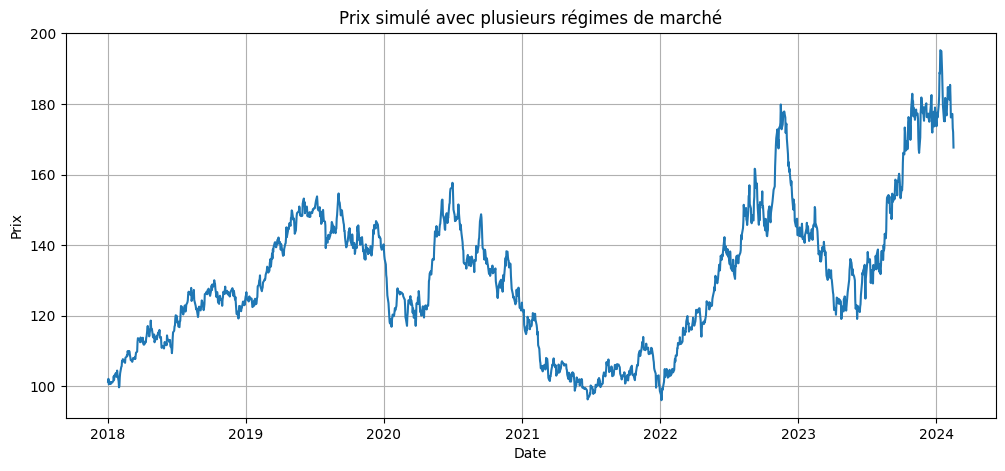

In [2]:

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["close"])
plt.title("Prix simulé avec plusieurs régimes de marché")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid(True)
plt.show()



## 6. Fonctions de backtest

La règle utilisée est volontairement simple.

Signal :

$$
\text{position}_t =
\begin{cases}
1 & \text{si } close_t > SMA_t \\
0 & \text{sinon}
\end{cases}
$$

Pour éviter le look-ahead bias, on décale la position d'une période :

$$
R_{strat,t} = position_{t-1} \times R_{market,t}
$$

Cela signifie que le signal observé aujourd'hui ne peut être tradé qu'à partir de la période suivante.


In [3]:

def backtest_sma_strategy(df, window):
    '''
    Backtest simple :
    - Long si le close est au-dessus de sa moyenne mobile.
    - Flat sinon.
    - Position décalée pour éviter le look-ahead bias.
    '''
    df = df.copy()
    df["sma"] = df["close"].rolling(window).mean()
    df["position"] = (df["close"] > df["sma"]).astype(int)
    df["strategy_return"] = df["position"].shift(1) * df["return"]
    df["strategy_return"] = df["strategy_return"].fillna(0)
    return df


def sharpe_ratio(returns, periods_per_year=252):
    '''
    Sharpe ratio annualisé, sans taux sans risque.
    '''
    if returns.std() == 0:
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / returns.std()


def evaluate_window(df, window):
    '''
    Retourne les métriques principales d'un backtest sur une fenêtre donnée.
    '''
    bt = backtest_sma_strategy(df, window)
    strat_ret = bt["strategy_return"]

    total_return = (1 + strat_ret).prod() - 1
    sharpe = sharpe_ratio(strat_ret)
    max_drawdown = ((1 + strat_ret).cumprod() / (1 + strat_ret).cumprod().cummax() - 1).min()

    return {
        "window": window,
        "total_return": total_return,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown
    }



## 7. Création des folds Walk-Forward

Nous allons utiliser :

- **500 jours** pour l'entraînement.
- **100 jours** pour le test.
- Un pas de progression de **100 jours**.

Ainsi, les segments **Out-of-Sample** ne se chevauchent pas.

C'est important, car si les tests OOS se chevauchent, les performances des folds deviennent dépendantes les unes des autres.


In [4]:

def create_walk_forward_folds(df, train_size=500, test_size=100, step_size=100):
    '''
    Crée des folds walk-forward sans chevauchement des segments OOS.
    '''
    folds = []
    start = 0

    while start + train_size + test_size <= len(df):
        train_start = start
        train_end = start + train_size
        test_start = train_end
        test_end = train_end + test_size

        folds.append({
            "train_start": train_start,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end,
            "train_data": df.iloc[train_start:train_end],
            "test_data": df.iloc[test_start:test_end]
        })

        start += step_size

    return folds


folds = create_walk_forward_folds(data, train_size=500, test_size=100, step_size=100)
len(folds)


11

In [5]:

fold_summary = pd.DataFrame([
    {
        "fold": i + 1,
        "train_start": fold["train_data"].index[0],
        "train_end": fold["train_data"].index[-1],
        "test_start": fold["test_data"].index[0],
        "test_end": fold["test_data"].index[-1],
    }
    for i, fold in enumerate(folds)
])

fold_summary


,fold,train_start,train_end,test_start,test_end
0,1,2018-01-01,2019-11-29,2019-12-02,2020-04-17
1,2,2018-05-21,2020-04-17,2020-04-20,2020-09-04
2,3,2018-10-08,2020-09-04,2020-09-07,2021-01-22
3,4,2019-02-25,2021-01-22,2021-01-25,2021-06-11
4,5,2019-07-15,2021-06-11,2021-06-14,2021-10-29
5,6,2019-12-02,2021-10-29,2021-11-01,2022-03-18
6,7,2020-04-20,2022-03-18,2022-03-21,2022-08-05
7,8,2020-09-07,2022-08-05,2022-08-08,2022-12-23
8,9,2021-01-25,2022-12-23,2022-12-26,2023-05-12
9,10,2021-06-14,2023-05-12,2023-05-15,2023-09-29


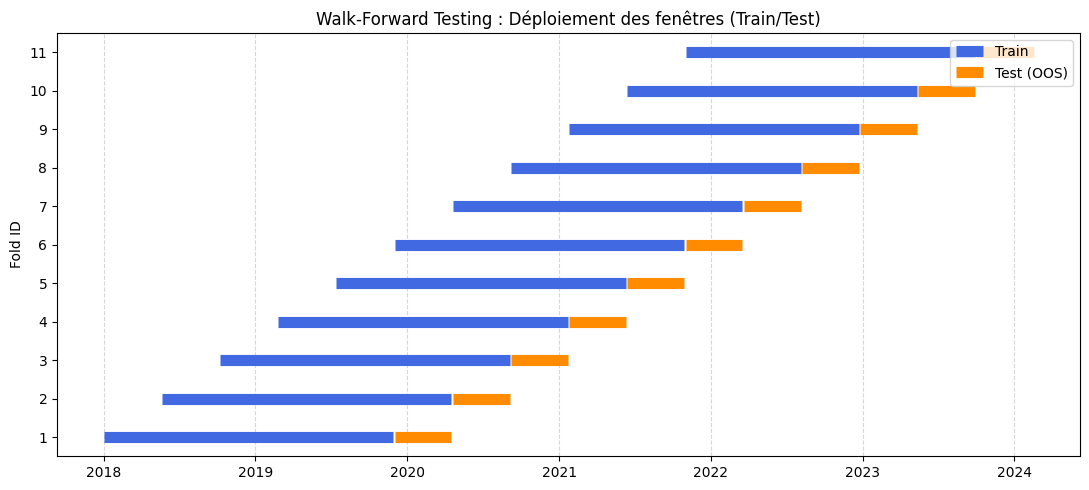

In [6]:
# Création de la figure
fig, ax = plt.subplots(figsize=(11, 5))

# Affichage des fenêtres Train et Test pour chaque Fold
for idx, row in fold_summary.iterrows():
    f_id = row['fold']
    
    # Segment d'entraînement (Train) en bleu
    ax.plot([row['train_start'], row['train_end']], [f_id, f_id], 
            color='royalblue', linewidth=8, solid_capstyle='butt', 
            label='Train' if idx == 0 else "")
    
    # Segment de test (Test - OOS) en orange
    ax.plot([row['test_start'], row['test_end']], [f_id, f_id], 
            color='darkorange', linewidth=8, solid_capstyle='butt', 
            label='Test (OOS)' if idx == 0 else "")

# Mise en forme du graphique
ax.set_yticks(fold_summary['fold'])
ax.set_ylabel("Fold ID")
ax.set_title("Walk-Forward Testing : Déploiement des fenêtres (Train/Test)")
ax.legend(loc='upper right')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



## 8. Optimisation In-Sample et test Out-of-Sample

Nous allons chercher la meilleure longueur de moyenne mobile parmi :

$$
\Theta = \{10, 20, 30, 50, 75, 100, 150, 200\}
$$

Pour chaque fold, le choix se fait uniquement sur le segment **In-Sample**.

Ensuite, la longueur choisie est appliquée sur le segment **Out-of-Sample**.


In [7]:

candidate_windows = [10, 20, 30, 50, 75, 100, 150, 200]

wf_results = []
oos_returns_list = []

for i, fold in enumerate(folds, start=1):
    train = fold["train_data"]
    test = fold["test_data"]

    # Optimisation sur le train uniquement
    train_scores = []
    for window in candidate_windows:
        metrics = evaluate_window(train, window)
        train_scores.append(metrics)

    train_scores_df = pd.DataFrame(train_scores)
    best_row = train_scores_df.sort_values("sharpe", ascending=False).iloc[0]
    best_window = int(best_row["window"])

    # Évaluation sur le test uniquement
    test_bt = backtest_sma_strategy(test, best_window)
    test_returns = test_bt["strategy_return"]

    test_metrics = {
        "fold": i,
        "best_window": best_window,
        "train_sharpe": best_row["sharpe"],
        "test_sharpe": sharpe_ratio(test_returns),
        "test_total_return": (1 + test_returns).prod() - 1,
        "test_max_drawdown": ((1 + test_returns).cumprod() / (1 + test_returns).cumprod().cummax() - 1).min(),
        "test_start": test.index[0],
        "test_end": test.index[-1]
    }

    wf_results.append(test_metrics)
    oos_returns_list.append(test_returns)

wf_results_df = pd.DataFrame(wf_results)
wf_results_df


,fold,best_window,train_sharpe,test_sharpe,test_total_return,test_max_drawdown,test_start,test_end
0,1,10,0.778897,0.262727,0.009148,-0.047751,2019-12-02,2020-04-17
1,2,10,0.818448,1.268101,0.075866,-0.088468,2020-04-20,2020-09-04
2,3,10,1.098990,-1.821266,-0.089322,-0.089322,2020-09-07,2021-01-22
3,4,10,0.654022,-3.042741,-0.100713,-0.101153,2021-01-25,2021-06-11
4,5,100,0.046142,NaN,0.000000,0.000000,2021-06-14,2021-10-29
5,6,50,0.164019,2.244928,0.094625,-0.036857,2021-11-01,2022-03-18
6,7,200,0.114095,NaN,0.000000,0.000000,2022-03-21,2022-08-05
7,8,200,1.024607,NaN,0.000000,0.000000,2022-08-08,2022-12-23
8,9,20,0.942781,-1.907672,-0.087147,-0.112602,2022-12-26,2023-05-12
9,10,100,1.146167,NaN,0.000000,0.000000,2023-05-15,2023-09-29



## 9. Analyse des paramètres choisis

Une question importante :

> Est-ce que le processus choisit toujours le même paramètre, ou bien s'adapte-t-il aux régimes ?

Si le meilleur paramètre change souvent, cela peut indiquer une adaptation.

Mais attention : cela peut aussi indiquer une instabilité excessive.

La bonne question n'est donc pas seulement :

> Quel est le meilleur paramètre ?

La vraie question EBTA est :

> Le processus de sélection des paramètres produit-il une performance OOS robuste ?


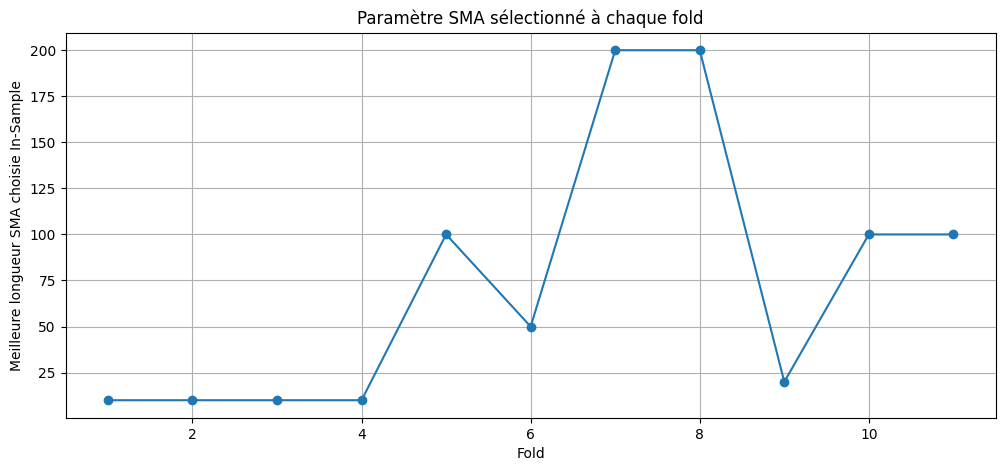

In [8]:

plt.figure(figsize=(12, 5))
plt.plot(wf_results_df["fold"], wf_results_df["best_window"], marker="o")
plt.title("Paramètre SMA sélectionné à chaque fold")
plt.xlabel("Fold")
plt.ylabel("Meilleure longueur SMA choisie In-Sample")
plt.grid(True)
plt.show()


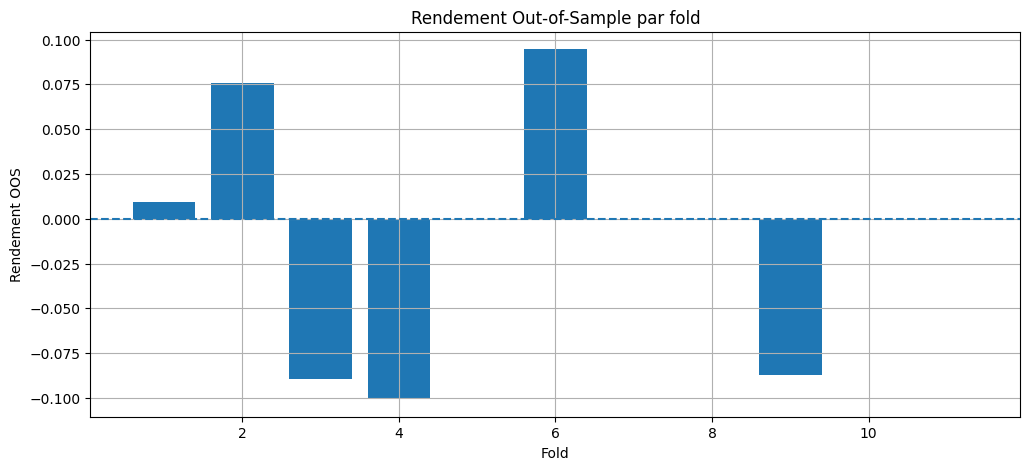

In [9]:

plt.figure(figsize=(12, 5))
plt.bar(wf_results_df["fold"], wf_results_df["test_total_return"])
plt.axhline(0, linestyle="--")
plt.title("Rendement Out-of-Sample par fold")
plt.xlabel("Fold")
plt.ylabel("Rendement OOS")
plt.grid(True)
plt.show()



## 10. Construction de l'equity curve Walk-Forward

Maintenant, on concatène tous les rendements **Out-of-Sample**.

Cela donne l'equity curve d'un trader qui aurait réellement suivi ce processus dans le temps.


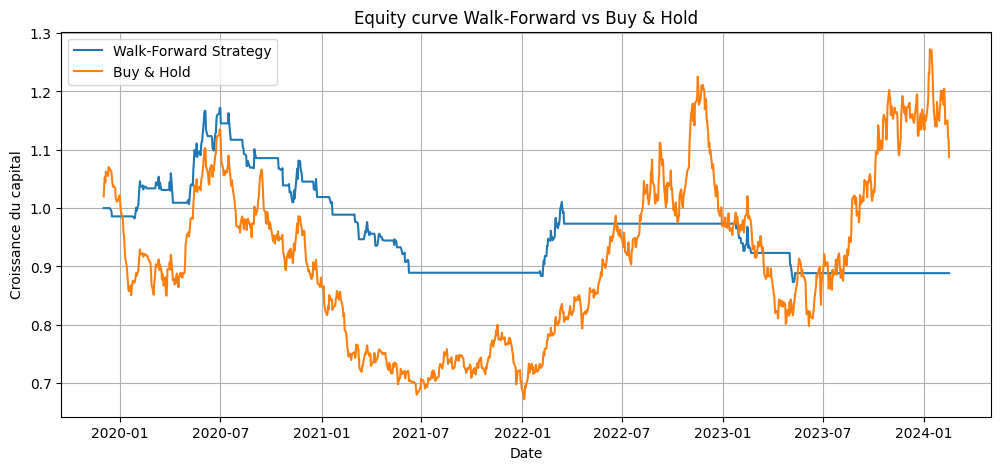

In [10]:

wf_oos_returns = pd.concat(oos_returns_list).sort_index()
wf_equity = (1 + wf_oos_returns).cumprod()

benchmark_returns = data.loc[wf_oos_returns.index, "return"]
benchmark_equity = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(wf_equity.index, wf_equity, label="Walk-Forward Strategy")
plt.plot(benchmark_equity.index, benchmark_equity, label="Buy & Hold")
plt.title("Equity curve Walk-Forward vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Croissance du capital")
plt.legend()
plt.grid(True)
plt.show()



## 11. Métriques globales Walk-Forward

Nous calculons maintenant les métriques agrégées sur toute la période hors-échantillon.


In [11]:

def max_drawdown_from_returns(returns):
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    return drawdown.min()

summary = pd.DataFrame({
    "Metric": [
        "Total OOS Return",
        "Annualized Sharpe OOS",
        "Max Drawdown OOS",
        "Number of OOS folds",
        "Average OOS fold return",
        "Std OOS fold return"
    ],
    "Value": [
        (1 + wf_oos_returns).prod() - 1,
        sharpe_ratio(wf_oos_returns),
        max_drawdown_from_returns(wf_oos_returns),
        len(wf_results_df),
        wf_results_df["test_total_return"].mean(),
        wf_results_df["test_total_return"].std()
    ]
})

summary


,Metric,Value
0,Total OOS Return,-0.111530
1,Annualized Sharpe OOS,-0.266281
2,Max Drawdown OOS,-0.254889
3,Number of OOS folds,11.000000
4,Average OOS fold return,-0.008867
5,Std OOS fold return,0.062964



## 12. Intervalle de confiance sur les folds OOS

L'un des intérêts du Walk-Forward est qu'il produit plusieurs observations hors-échantillon.

On peut donc estimer l'incertitude de la performance.

Soit :

- $\bar{x}$ : rendement moyen OOS par fold.
- $s$ : écart-type des rendements OOS par fold.
- $K$ : nombre de folds.

L'erreur standard est :

$$
SE = \frac{s}{\sqrt{K}}
$$

Un intervalle de confiance approximatif à $95\%$ est :

$$
IC_{95\%} = \bar{x} \pm 1.96 \times SE
$$

Attention : cette approximation est plus crédible si les folds OOS sont suffisamment indépendants.


In [12]:

fold_returns = wf_results_df["test_total_return"]
mean_fold_return = fold_returns.mean()
std_fold_return = fold_returns.std(ddof=1)
k = len(fold_returns)

standard_error = std_fold_return / np.sqrt(k)
ci_low = mean_fold_return - 1.96 * standard_error
ci_high = mean_fold_return + 1.96 * standard_error

ci_table = pd.DataFrame({
    "Statistic": [
        "Mean OOS fold return",
        "Standard deviation",
        "Standard error",
        "95% CI lower bound",
        "95% CI upper bound"
    ],
    "Value": [
        mean_fold_return,
        std_fold_return,
        standard_error,
        ci_low,
        ci_high
    ]
})

ci_table


,Statistic,Value
0,Mean OOS fold return,-0.008867
1,Standard deviation,0.062964
2,Standard error,0.018984
3,95% CI lower bound,-0.046077
4,95% CI upper bound,0.028342


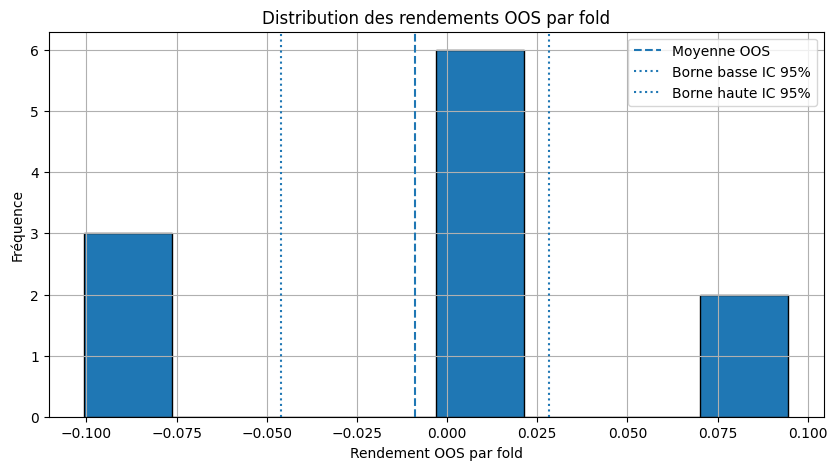

In [13]:

plt.figure(figsize=(10, 5))
plt.hist(fold_returns, bins=8, edgecolor="black")
plt.axvline(mean_fold_return, linestyle="--", label="Moyenne OOS")
plt.axvline(ci_low, linestyle=":", label="Borne basse IC 95%")
plt.axvline(ci_high, linestyle=":", label="Borne haute IC 95%")
plt.title("Distribution des rendements OOS par fold")
plt.xlabel("Rendement OOS par fold")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()



## 13. Interprétation EBTA

Le Walk-Forward est puissant, mais il ne rend pas automatiquement une stratégie valide.

Il peut lui aussi être mal utilisé.

### Ce qu'il améliore

- Il réduit le risque de sélectionner un paramètre uniquement chanceux sur tout l'historique.
- Il simule une logique de trading plus réaliste.
- Il permet d'observer la stabilité temporelle de la stratégie.
- Il donne plusieurs performances OOS au lieu d'un seul test final.

### Ce qu'il ne résout pas complètement

- Si tu testes trop de variantes de processus Walk-Forward, tu peux créer un nouveau biais de minage.
- Si les folds OOS sont trop courts, les résultats restent très bruités.
- Si les segments OOS se chevauchent, l'indépendance statistique est affaiblie.
- Si tu ajustes la méthode après avoir vu les résultats OOS, tu souilles le test.

> Le Walk-Forward n'est pas une permission de sur-optimiser.  
> C'est une discipline pour limiter l'illusion de robustesse.



## 14. La règle d'or pour un trader EBTA

Pour utiliser correctement le Walk-Forward :

| Décision | Bonne pratique |
|---|---|
| Longueur In-Sample | Assez longue pour estimer les paramètres |
| Longueur Out-of-Sample | Assez longue pour mesurer une vraie performance |
| Chevauchement OOS | À éviter si l'objectif est l'inférence statistique |
| Critère d'optimisation | Défini avant le test |
| Univers de paramètres | Défini avant le test |
| Analyse finale | Basée sur les performances OOS uniquement |

> L'Eurêka final : ce n'est pas le meilleur paramètre qui compte.  
> Ce qui compte, c'est la robustesse du **processus qui choisit le paramètre**.



## 15. Checklist pratique pour tes backtests

Avant de faire un Walk-Forward, vérifie :

- As-tu défini les paramètres candidats avant le test ?
- As-tu choisi une seule métrique d'optimisation principale ?
- Les données OOS sont-elles totalement absentes de la phase d'optimisation ?
- Les folds OOS se chevauchent-ils ?
- Le nombre de folds est-il suffisant pour observer la stabilité ?
- La performance est-elle concentrée sur un seul fold ou répartie ?
- Les paramètres choisis sont-ils cohérents ou totalement erratiques ?
- Le résultat reste-t-il bon après coûts, spread, slippage et commissions ?

Cette checklist protège contre le piège suivant :

> Croire qu'un système est robuste parce qu'il a été testé avec une méthode sophistiquée, alors que la sophistication a simplement déplacé le biais ailleurs.



## 16. Résumé ultra-simple

Le **Walk-Forward Testing**, c'est :

> Apprendre sur le passé récent, tester sur le futur immédiat, avancer, répéter.

Il sert à tester une stratégie ou un processus d'optimisation dans un environnement où le marché change.

Il est particulièrement utile lorsque :

- les paramètres doivent s'adapter au régime de marché,
- tu veux éviter un simple split statique,
- tu veux observer la robustesse temporelle,
- tu veux obtenir plusieurs estimations OOS indépendantes.

Mais il doit être utilisé proprement :

> Si tu modifies ton processus après avoir regardé les résultats OOS, tu transformes ton Walk-Forward en nouveau data mining.



## 17. Mini-exercice

Modifie les paramètres suivants dans le code :

```python
train_size = 500
test_size = 100
step_size = 100
candidate_windows = [10, 20, 30, 50, 75, 100, 150, 200]
```

Puis observe :

1. Est-ce que la performance OOS change beaucoup ?
2. Est-ce que les paramètres choisis deviennent plus stables ?
3. Est-ce que la stratégie dépend d'un seul fold gagnant ?
4. Est-ce que l'intervalle de confiance reste positif ?
5. Est-ce que le Buy & Hold fait mieux ou moins bien ?

Objectif :

> Ne cherche pas seulement à maximiser la performance.  
> Cherche à comprendre la stabilité du processus.


## Annexe : texte source

### **CH 6 : WALK-FORWARD TESTING**

Cette section détaille une approche de segmentation des données plus sophistiquée et dynamique, conçue pour simuler le comportement d'une règle de trading qui s'adapte à l'évolution des marchés.

---

#### **Idées clés :**
*   **Segmentation dynamique :** Contrairement aux tests statiques, le Walk-Forward utilise une fenêtre de données mobile qui glisse le long de l'axe du temps.
*   **Structure par "Plis" (Folds) :** Chaque fenêtre est divisée en un segment d'entraînement (In-Sample) et un segment de test (Out-of-Sample).
*   **Apprentissage continu :** Le processus simule une règle qui "apprend" ses meilleurs paramètres sur les données passées avant d'être évaluée sur des données nouvelles.
*   **Adaptation à la non-stationnarité :** Cette méthode est particulièrement pertinente pour les marchés financiers dont les dynamiques changent au fil du temps.

---

#### **Référence :**
*Walk-Forward Testing*, Chapitre 6, pages 322 à 324.

---

#### **Citation Directe :**
« It employs a moving data window, which itself is divided into an in-sample and out-of-sample segment. [...] The terminology alludes to a rule that is learning from its experience. » (Page 322).

---

#### **Vision Macro :**
L'enjeu philosophique est la gestion de l'évolution du marché, ou "non-stationnarité". David Aronson explique que le Walk-Forward ne teste pas simplement la performance d'une règle fixe, mais valide l'efficacité du *processus d'optimisation* lui-même. C'est une simulation réaliste d'un trader systématique qui réajuste périodiquement ses modèles pour rester en phase avec les nouvelles conditions de marché.

---

#### **Vision Micro :**
Le mécanisme technique du Walk-Forward repose sur une procédure itérative rigoureuse :

1.  **Le Pli (Fold) :** On définit un bloc de données composé d'un segment d'entraînement (Training Set) et d'un segment de test (Testing Set).
2.  **Optimisation (In-Sample) :** Les paramètres optimaux de la règle sont recherchés exclusivement sur le segment d'entraînement.
3.  **Évaluation (Out-of-Sample) :** La règle avec ces paramètres est ensuite appliquée au segment de test pour obtenir une estimation non biaisée de sa performance.
4.  **Progression temporelle :** La fenêtre complète (entraînement + test) avance dans le temps, et l'opération est répétée sur un nouveau pli.
5.  **Indépendance statistique :** Aronson insiste sur le fait que la fenêtre doit avancer suffisamment pour que les segments de test de chaque pli ne se chevauchent pas, garantissant ainsi que les estimations de performance sont statistiquement indépendantes.
6.  **Analyse des résultats :** L'accumulation de ces résultats hors-échantillon permet de calculer la variance de la performance et de construire des intervalles de confiance robustes.

---

#### **Résumé Simplifié :**
Le Walk-Forward est comme un entraînement sportif continu. Au lieu de passer un seul examen final après 10 ans d'études, vous passez un petit examen chaque année basé sur ce que vous avez appris l'année précédente. Si vous réussissez ces examens successifs, cela prouve que votre méthode d'apprentissage est solide et capable de s'adapter aux changements.

---

#### **Actions Concrètes :**
*   **Diviser l'historique en plusieurs plis :** Ne vous contentez pas d'un seul test final ; créez une série de fenêtres successives.
*   **Interdire le chevauchement des tests :** Assurez-vous que les données utilisées pour évaluer un pli n'apparaissent jamais dans le test d'un autre pli pour ne pas fausser les statistiques.
*   **Utiliser pour les systèmes adaptatifs :** Privilégiez cette méthode si votre stratégie repose sur des indicateurs dont les réglages (ex: longueur d'une moyenne mobile) doivent varier selon le régime de marché.
*   **Calculer la stabilité :** Comparez les performances d'un pli à l'autre pour vérifier si la stratégie est constante ou si elle est trop dépendante de périodes spécifiques.

---

#### **À retenir absolument :**
*   Le Walk-Forward est une **méthode de segmentation dynamique**.
*   Il est conçu pour les systèmes **non stationnaires** (marchés changeants).
*   Chaque pli fournit une **estimation de performance honnête** et non biaisée.
*   La **non-superposition des segments de test** est cruciale pour la validité.
*   Il permet de mesurer la **robustesse temporelle** du processus de trading.

J'ai terminé l'analyse de la section sur le Walk-Forward Testing selon le protocole EBTA.